# 🌳 Chapter 8: Tree-Based Algorithms
**Book Reference:** *scikit-learn Cookbook, Third Edition*

---
## 1. Introduction
Decision Trees work by splitting the data space using conditional rule boundaries (*if-else* statements). We will explore everything from a single tree model to advanced *ensemble* methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

%matplotlib inline
np.random.seed(42)

X, y = make_classification(n_samples=500, n_features=4, n_informative=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## 2. Decision Tree Classifier
While highly interpretable, trees that grow too deep are prone to memorizing the training records (*overfitting*). We will mitigate this risk by constraining their maximum vertical growth via the `max_depth` parameter.

Decision Tree Accuracy: 0.933


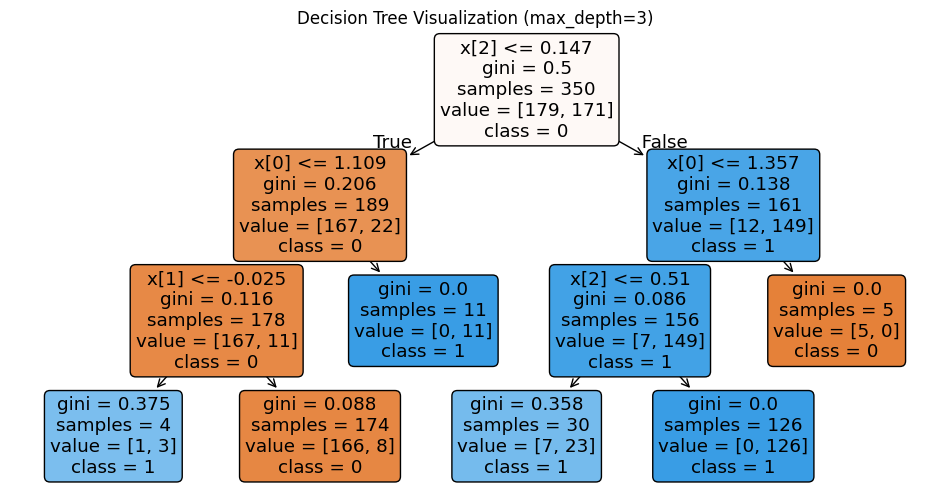

In [2]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt.predict(X_test)):.3f}")

plt.figure(figsize=(12, 6))
plot_tree(dt, filled=True, rounded=True, class_names=['0', '1'])
plt.title('Decision Tree Visualization (max_depth=3)')
plt.show()

## 3. Ensemble: Random Forest & Gradient Boosting
Ensemble methods combine hundreds of individual decision trees together to construct a single robust, high-performance predictor.

Random Forest Accuracy: 0.960
Gradient Boosting Accuracy: 0.940


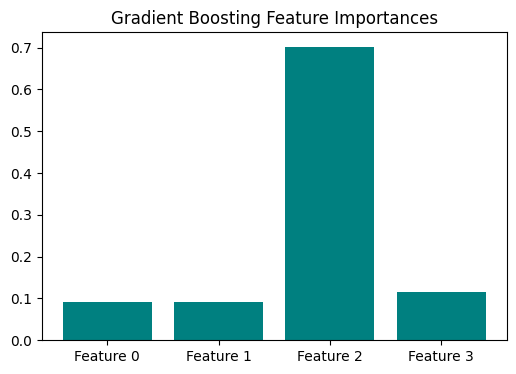

In [3]:
# Random Forest (Parallel processing assembly)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf.predict(X_test)):.3f}")

# Gradient Boosting (Sequential training progression)
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb.predict(X_test)):.3f}")

# Feature Importance Mapping
plt.figure(figsize=(6, 4))
plt.bar([f'Feature {i}' for i in range(4)], gb.feature_importances_, color='teal')
plt.title('Gradient Boosting Feature Importances')
plt.show()